In [9]:
import pandas as pd

ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")

df = pd.concat([ethiopia, kenya, nigeria, sudan, tanzania])
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


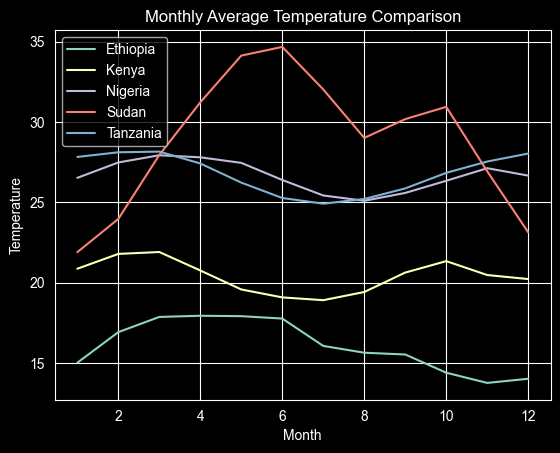

In [10]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby(["Country", "Month"])["T2M"].mean().reset_index()

plt.figure()

for country in monthly_temp["Country"].unique():
    subset = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(subset["Month"], subset["T2M"], label=country)

plt.legend()
plt.title("Monthly Average Temperature Comparison")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()

In [11]:
temp_summary = df.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


In [12]:
df = df.reset_index(drop=True)

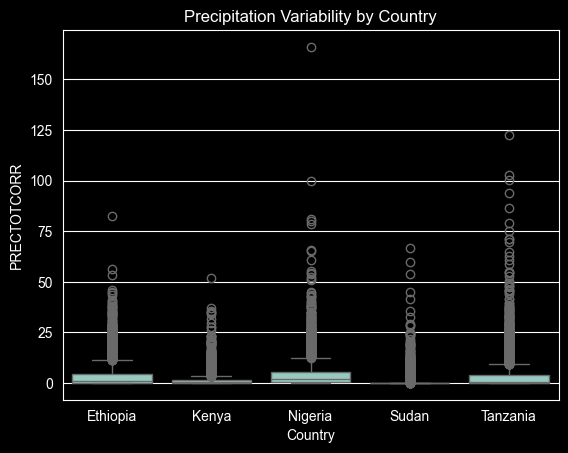

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(x="Country", y="PRECTOTCORR", data=df)
plt.title("Precipitation Variability by Country")
plt.show()

In [15]:
vulnerability = df.groupby("Country").agg({
    "T2M": "mean",
    "PRECTOTCORR": "std"
}).rename(columns={
    "T2M": "Avg_Temp",
    "PRECTOTCORR": "Rainfall_Variability"
})

vulnerability = vulnerability.sort_values(
    by=["Avg_Temp", "Rainfall_Variability"],
    ascending=[False, False]
)

vulnerability

,Avg_Temp,Rainfall_Variability
Country,,
Sudan,28.759007,3.057672
Tanzania,26.802422,8.003947
Nigeria,26.656928,7.266742
Kenya,20.427600,3.180228
Ethiopia,16.068500,6.289061


In [ ]:
### COP32 Climate Findings Report
#
# *   **Sudan** exhibits the most extreme seasonal temperature spikes, reaching nearly 35°C in mid-year, which suggests a vulnerability to intense, periodic heat stress compared to the more stable profiles of its neighbors.
# *   **Nigeria** possesses the most unstable precipitation patterns, with extreme outliers reaching above 150 PRECTOTCORR, indicating a high frequency of intense and unpredictable rainfall events.
# *   The data reveals that countries like **Sudan** face acute climate stress, as record-high temperatures coincide with the lowest median precipitation levels, signaling high risks for chronic drought,.
# *   Compared to its neighbors, **Ethiopia** maintains a much cooler and more temperate climate profile, with the lowest monthly average temperatures in the region and moderate precipitation variability,.
# *   Ethiopia should champion **Sudan** for priority climate finance, as the data highlights its extreme dual vulnerability to both the highest regional temperatures and the most restricted rainfall,.